C:\Users\User\AppData\Local\Temp\ipykernel_46828\3101400050.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_locat

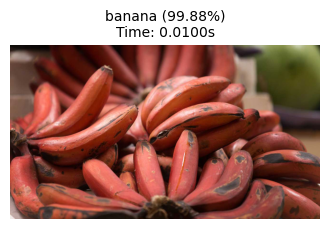


111.jpg
   apple: 0.00%
   banana: 99.88%
   orange: 0.12%
Top predictions:
   banana: 99.88%
   orange: 0.12%
   apple: 0.00%


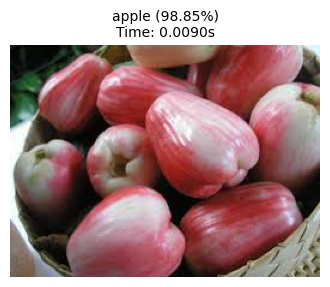


11111111.jfif
   apple: 98.85%
   banana: 0.50%
   orange: 0.65%
Top predictions:
   apple: 98.85%
   orange: 0.65%
   banana: 0.50%


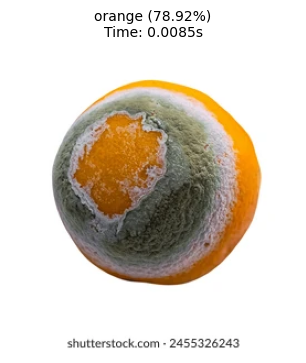


111111111111.webp
   apple: 20.57%
   banana: 0.51%
   orange: 78.92%
Top predictions:
   orange: 78.92%
   apple: 20.57%
   banana: 0.51%


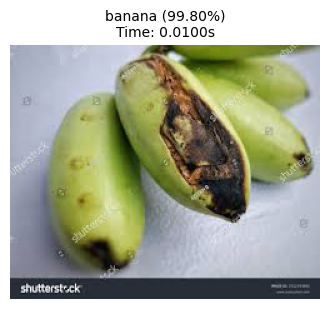


dddd.jfif
   apple: 0.20%
   banana: 99.80%
   orange: 0.00%
Top predictions:
   banana: 99.80%
   apple: 0.20%
   orange: 0.00%


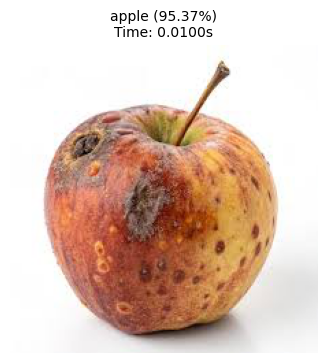


ddssss.jfif
   apple: 95.37%
   banana: 2.30%
   orange: 2.33%
Top predictions:
   apple: 95.37%
   orange: 2.33%
   banana: 2.30%


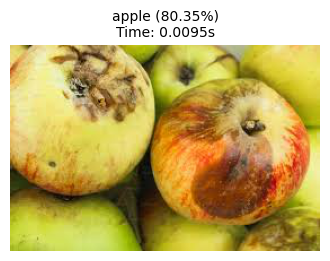


dfdfdfd.jfif
   apple: 80.35%
   banana: 19.24%
   orange: 0.41%
Top predictions:
   apple: 80.35%
   banana: 19.24%
   orange: 0.41%


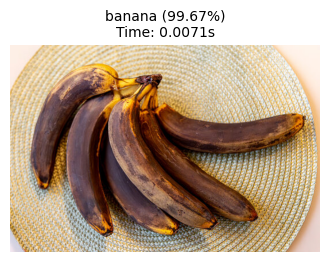


dsssssssssss.jpg
   apple: 0.11%
   banana: 99.67%
   orange: 0.22%
Top predictions:
   banana: 99.67%
   orange: 0.22%
   apple: 0.11%


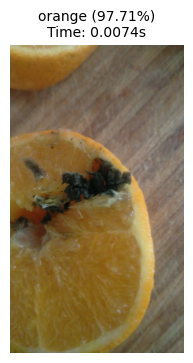


orororor.jpg
   apple: 0.12%
   banana: 2.17%
   orange: 97.71%
Top predictions:
   orange: 97.71%
   banana: 2.17%
   apple: 0.12%


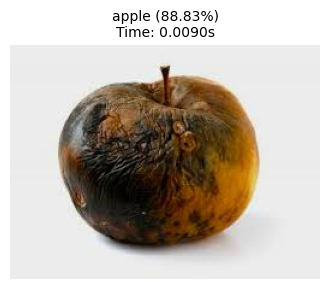


sada.jfif
   apple: 88.83%
   banana: 5.82%
   orange: 5.36%
Top predictions:
   apple: 88.83%
   banana: 5.82%
   orange: 5.36%


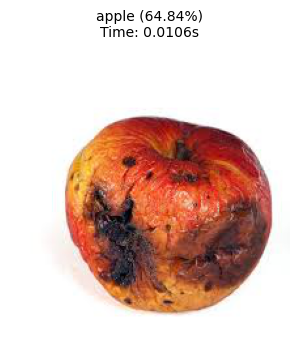


sadaaaa.jfif
   apple: 64.84%
   banana: 5.26%
   orange: 29.90%
Top predictions:
   apple: 64.84%
   orange: 29.90%
   banana: 5.26%


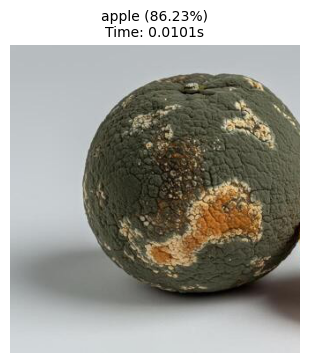


sdasdadsada.jpeg
   apple: 86.23%
   banana: 3.08%
   orange: 10.70%
Top predictions:
   apple: 86.23%
   orange: 10.70%
   banana: 3.08%

Average inference time: 0.0092 sec
FPS: 108.65


In [9]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import time
import random

device = torch.device("cpu")

model = models.mobilenet_v2(pretrained=True)

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.last_channel, 3)
    )
)

model.load_state_dict(torch.load("best_model.pth", map_location=device))

model.to(device)
model.eval()

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

folder_path = "TryData/test"
class_names = ["apple", "banana", "orange"]

results = []

for img_name in os.listdir(folder_path):

    img_path = os.path.join(folder_path, img_name)

    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    start = time.time()
    with torch.no_grad():
        output = model(input_tensor)
    end = time.time()

    inference_time = end - start

    probs = torch.softmax(output, dim=1)[0]
    pred_idx = torch.argmax(probs).item()
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx].item()

    # save result
    results.append({
        "image": img_name,
        "pred": pred_class,
        "conf": confidence,
        "time": inference_time
    })

    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"{pred_class} ({confidence*100:.2f}%)\n"
        f"Time: {inference_time:.4f}s",
        fontsize=10
    )

    plt.show()

    print(f"\n{img_name}")
    for name, prob in zip(class_names, probs):
        print(f"   {name}: {prob.item()*100:.2f}%")

    sorted_probs, indices = torch.sort(probs, descending=True)

    print("Top predictions:")
    for idx in indices:
        print(f"   {class_names[idx]}: {probs[idx].item()*100:.2f}%")

avg_time = sum(r["time"] for r in results) / len(results)

print("\n=========================")
print(f"Average inference time: {avg_time:.4f} sec")
print(f"FPS: {1/avg_time:.2f}")